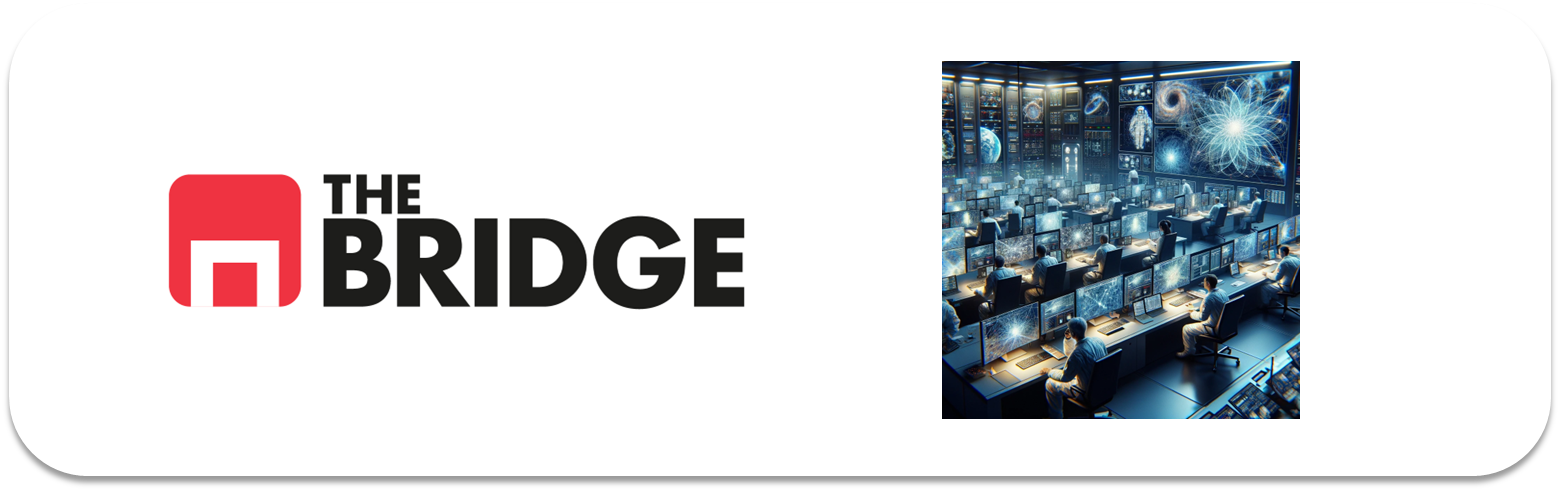

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import os
import cv2
import numpy as np

IMG_SIZE = 32

def load_images_from_folder(folder):
    X = []
    y = []
    
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            
            # etiqueta desde nombre archivo
            if "dog" in filename.lower():
                y.append(0)
            else:
                y.append(1)
    
    return np.array(X), np.array(y)

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [3]:
folders = ["./data/github_train_0", "./data/github_train_1",
           "./data/github_train_2", "./data/github_train_3"]

X_train = []
y_train = []

for folder in folders:
    X, y = load_images_from_folder(folder)
    X_train.append(X)
    y_train.append(y)

X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

In [4]:
X_test, y_test = load_images_from_folder("./data/github_test")

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

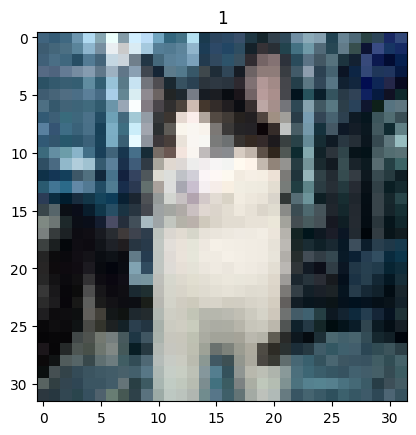

In [6]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0])
plt.title(y_train[0])
plt.show()

In [18]:


print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Perros en train:", np.sum(y_train == 0))
print("Gatos en train:", np.sum(y_train == 1))
print("Perros en test:", np.sum(y_test == 0))
print("Gatos en test:", np.sum(y_test == 1))

Shape X_train: (4000, 32, 32, 3)
Shape X_test: (1000, 32, 32, 3)
Perros en train: 2000
Gatos en train: 2000
Perros en test: 500
Gatos en test: 500


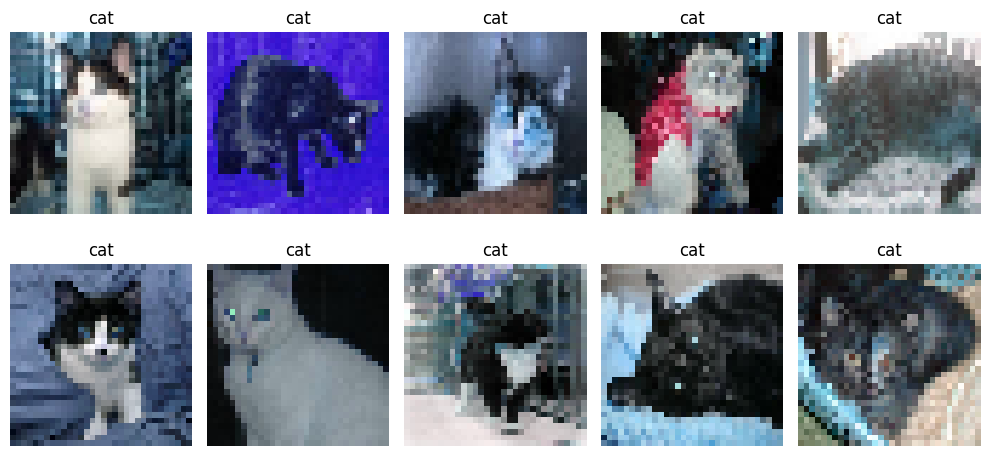

In [19]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title("dog" if y_train[i] == 0 else "cat")
    plt.axis("off")
plt.tight_layout()
plt.show()

-Se usa una CNN porque las imágenes tienen estructura espacial
-Las capas convolucionales detectan patrones locales
-El pooling reduce dimensionalidad
-Dropout ayuda a evitar overfitting
-sigmoid se usa porque es clasificación binaria

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    
    Dense(64, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')  # binario
])

c:\Users\Rebeca\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6162 - loss: 0.6714 - val_accuracy: 0.0000e+00 - val_loss: 0.9772
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6284 - loss: 0.6423 - val_accuracy: 0.0262 - val_loss: 1.1868
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6625 - loss: 0.6126 - val_accuracy: 0.2650 - val_loss: 0.9450
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6812 - loss: 0.5842 - val_accuracy: 0.3487 - val_loss: 0.9424
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7088 - loss: 0.5637 - val_accuracy: 0.4750 - val_loss: 0.8062
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7256 - loss: 0.5524 - val_accuracy: 0.5312 - val_loss: 0.7731
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7409 - loss: 0.5180 - val_accuracy: 0.4625 - val_loss: 0.8584
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7694 - loss: 0.4910 - val_accuracy

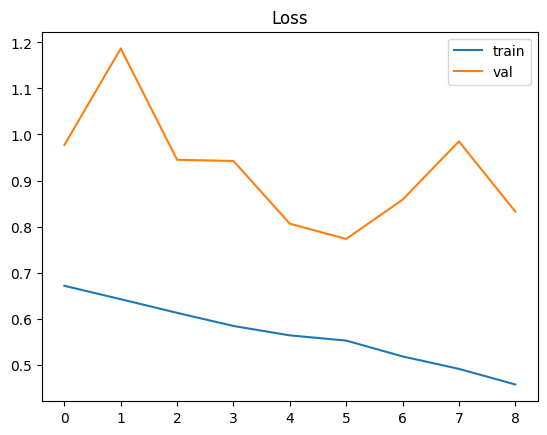

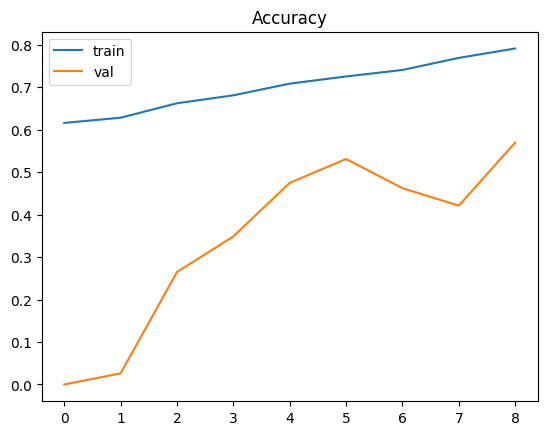

In [10]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0       0.78      0.52      0.63       500
           1       0.64      0.86      0.73       500

    accuracy                           0.69      1000
   macro avg       0.71      0.69      0.68      1000
weighted avg       0.71      0.69      0.68      1000



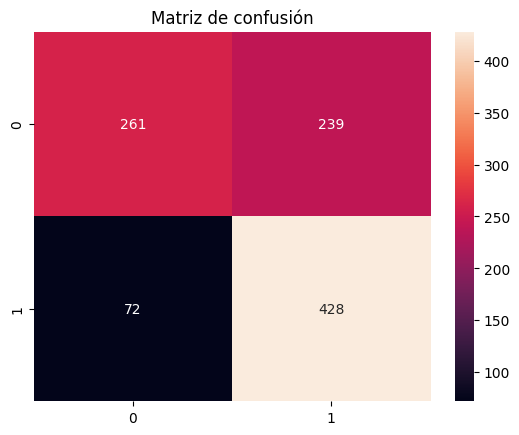

In [12]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matriz de confusión")
plt.show()

El modelo presenta un rendimiento moderado, con una accuracy cercana al 69%.
La matriz de confusión y el classification report muestran que la clase 1 se detecta mucho mejor que la clase 0, por lo que el modelo tiene un sesgo hacia una de las clases. Esto puede deberse a la complejidad de las imágenes, al tamaño reducido de entrada (32x32) o a una arquitectura todavía sencilla.

In [13]:
probs = model.predict(X_test).flatten()

misclassified = np.where(y_test != y_pred.flatten())[0]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [14]:
# perros mal clasificados como gatos
dogs_wrong = [i for i in misclassified if y_test[i] == 0]

# gatos mal clasificados como perros
cats_wrong = [i for i in misclassified if y_test[i] == 1]

In [15]:
def top_confused(indices, probs, y_true, top=0.1):
    confidences = []
    
    for i in indices:
        if y_true[i] == 0:
            conf = probs[i]  # cree que es gato
        else:
            conf = 1 - probs[i]
        confidences.append((i, conf))
    
    confidences.sort(key=lambda x: x[1], reverse=True)
    
    n = int(len(confidences) * top)
    return [i for i,_ in confidences[:n]]

In [16]:
top_dogs = top_confused(dogs_wrong, probs, y_test)
top_cats = top_confused(cats_wrong, probs, y_test)

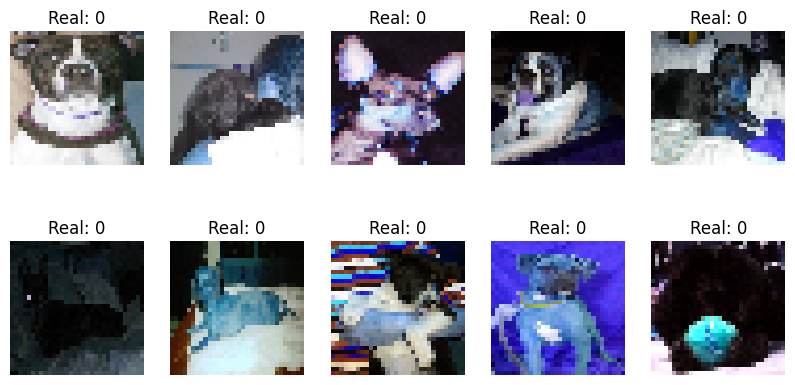

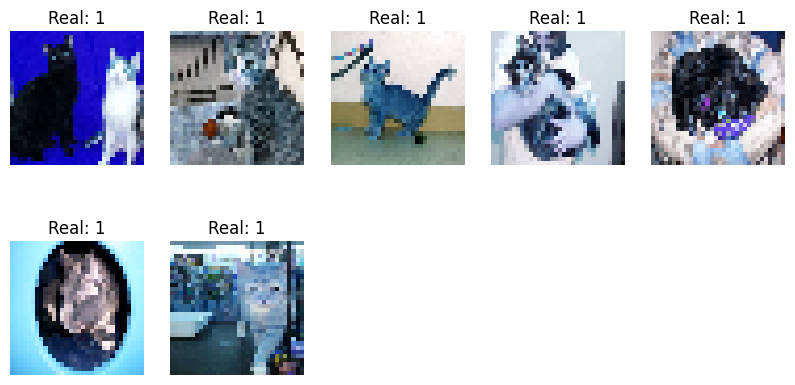

In [17]:
def show_images(indices, X, y):
    plt.figure(figsize=(10,5))
    for i, idx in enumerate(indices[:10]):
        plt.subplot(2,5,i+1)
        plt.imshow(X[idx])
        plt.title(f"Real: {y[idx]}")
        plt.axis('off')
    plt.show()

show_images(top_dogs, X_test, y_test)
show_images(top_cats, X_test, y_test)

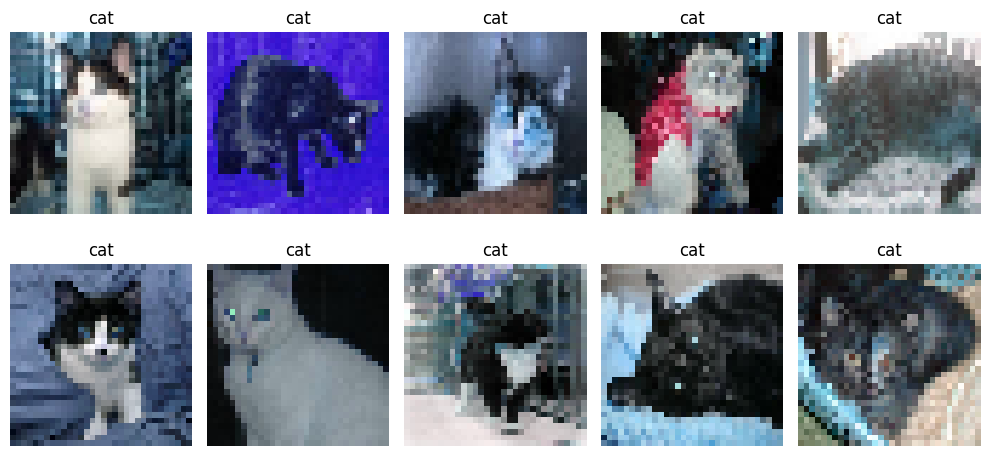

In [23]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title("dog" if y_train[i] == 0 else "cat")
    plt.axis("off")
plt.tight_layout()
plt.show()

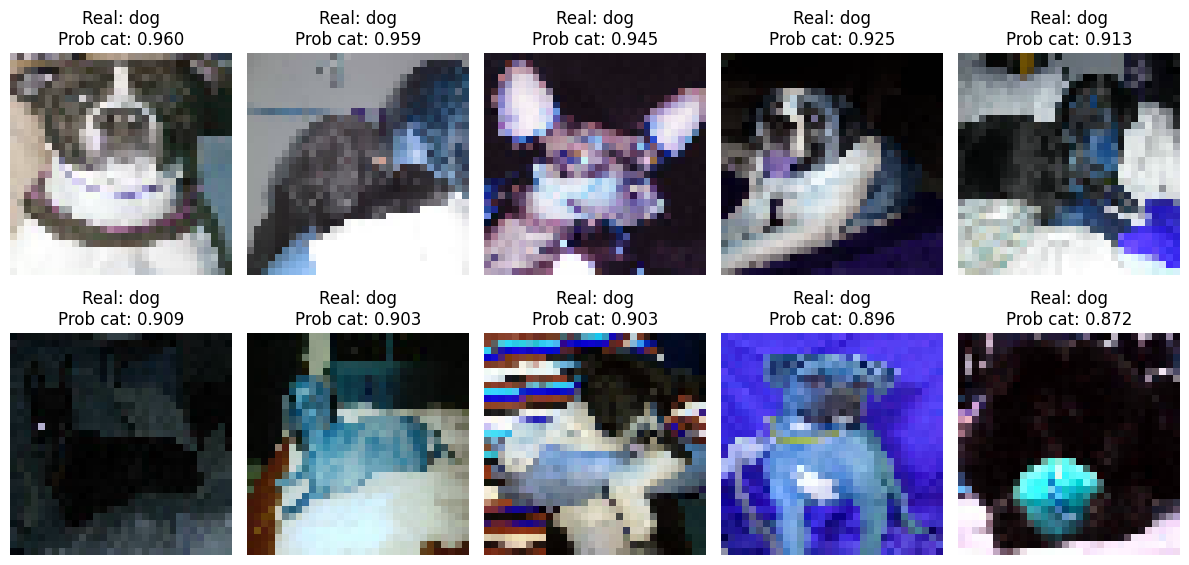

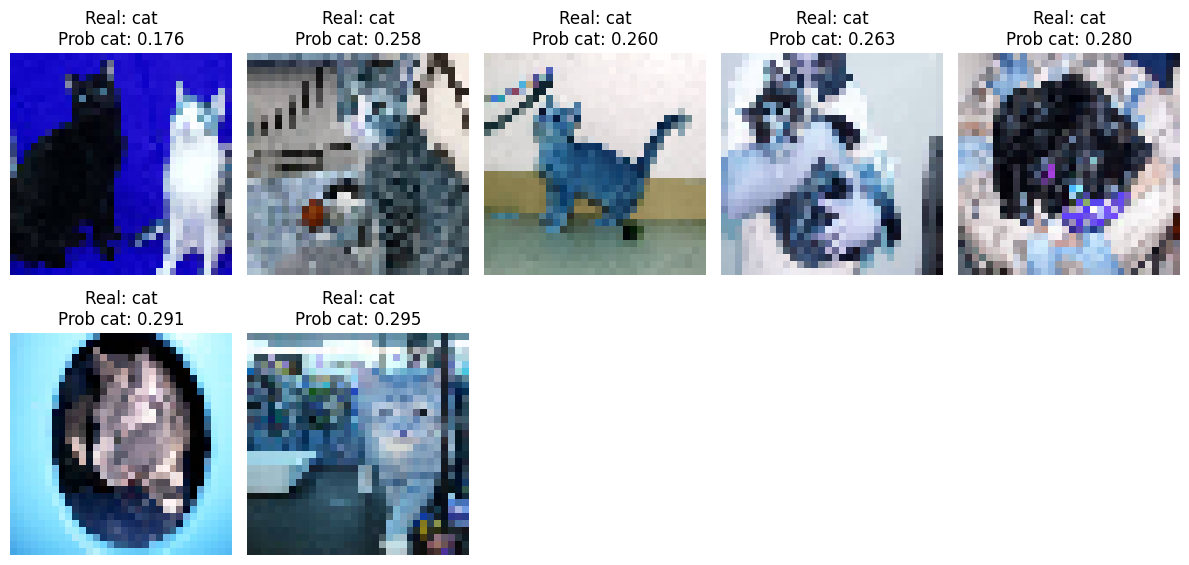

In [21]:
show_images(top_dogs, X_test, y_test, probs)
show_images(top_cats, X_test, y_test, probs)

In [22]:
print("Total mal clasificadas:", len(misclassified))
print("Perros mal clasificados como gatos:", len(dogs_wrong))
print("Gatos mal clasificados como perros:", len(cats_wrong))
print("Top 10% perros difíciles:", len(top_dogs))
print("Top 10% gatos difíciles:", len(top_cats))

Total mal clasificadas: 311
Perros mal clasificados como gatos: 239
Gatos mal clasificados como perros: 72
Top 10% perros difíciles: 23
Top 10% gatos difíciles: 7


En el caso de los perros mal clasificados, se seleccionan aquellos ejemplos para los que el modelo asigna una probabilidad más alta de pertenecer a la clase “gato”.
En el caso de los gatos mal clasificados, se seleccionan aquellos ejemplos para los que el modelo asigna una probabilidad más alta de pertenecer a la clase “perro”.